In [18]:
#the purpose of this script is to calculate portfolio VaR on a simple portfoio
#of equities

import yfinance as yf
import pandas as pd
import numpy as np
import scipy 
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats
from datetime import datetime


#set some portfolio variables
tickers = ['AAPL','JPM','XOM','JNJ','PG']

w = {'AAPL': .25, 'JPM': .2, 'XOM': .15, 'JNJ': .2, 'PG': .2}
port_val = 1000000
rf = .04
startdt = "2019-01-01"
enddt = "2026-09-01"

#get the difference between the two dates in years
datediff = datetime.strptime(enddt, "%Y-%m-%d").date() - datetime.strptime(startdt, "%Y-%m-%d").date()

Gather data and set up variables

In [19]:
#download all the data
df_data = yf.download(tickers, start=startdt, end=enddt, auto_adjust=True)['Close']

[*********************100%***********************]  5 of 5 completed


In [20]:
#loop through the columns and calculate the return from the previous row
for i in df_data.columns:

    #isolate the previous row for each price
    prev_R = df_data[i].shift(1)

    #calculate the daily log returns of each security. using ln of the previous row as an approximation
    df_data[i + '_p'] = df_data.apply(lambda x: np.log((x[i]/prev_R[x.name])) if pd.notna(prev_R[x.name]) else 0, axis=1 )

#create a new dataframe and drop the original price values
df_data_p = df_data.drop(columns=tickers)

#remove the "_p" from each column name here so the matrices further down are formatted more cleanly
for c in df_data_p.columns:
    df_data_p.rename(columns={c: c[:-2]}, inplace=True) #strip the "_p" off the column name

#drop rows where all values are 0
df_data_p = df_data_p.loc[(df_data_p != 0).any(axis=1), :]

#sort the dataframe columns and dictionary so we know that we are on the same page
df_data_pw = df_data_p.sort_index(axis=1)
w = dict(sorted(w.items()))

Calculate Portfolio Stats

In [21]:
# multiply all columns by their weights
df_data_pw = df_data_pw * list(w.values())

#put the total return into a new DataFrame for just the portfolio
df_pr = pd.DataFrame(df_data_pw.sum(axis=1))

#rename the column Total_return
df_pr.rename(columns={0:'Total_Return'}, inplace=True)
df_pr['Cumulative_Sum'] = df_pr['Total_Return'].cumsum()

#create a column that shows the portfolio value at each date
df_pr['Portfolio_Value'] = (port_val * (np.exp(df_pr.iloc[:, 0]).cumprod())).round(2)

#return the cumulative maximum as of each row
df_pr['Peak_Val'] = df_pr['Portfolio_Value'].cummax()

#calculate the difference between each row's value and the previous max value
df_pr['Peak_Diff'] = df_pr['Portfolio_Value'] - df_pr['Peak_Val']

#calculate drawdown percentage at each date
df_pr['Drawdown'] = df_pr['Peak_Diff'] / df_pr['Peak_Val']

In [22]:
#calculate annualized return
r = df_pr['Total_Return'].sum() #this is the return
ar = (np.exp(r) ** (365/datediff.days) - 1) #this is the annualized return

#calculate the portfolio standard deviation
wa = np.array(list(w.values()))  #get the weights from the sorted dictionary
cov = np.cov(df_data_p, rowvar=False) #calculate covariance matrix
sd = np.sqrt(wa @ cov @ wa) #calculate daily portfolio standard deviation
sd_a = sd * np.sqrt(252) #annualized standard deviation
#sd = df_pr['Total_Return'].std() * np.sqrt(252)  #alternate method for standard deviation

#calculate sharpe ratio
sr = (ar - rf) / sd_a  #calculate the Sharpe Ratio

#calculate max drawdown
mdd = df_pr['Drawdown'].min()

#calculate correlation matrix
corr_matrix = df_data_p.corr(numeric_only=True)

#calculate daily portfolio mean
m = df_pr['Total_Return'].mean()

#print("Annualized Return: {}, \n Sharpe Ratio: {}, \n Max Drawdown: {}, \n Standard Deviaion: {}".format(ar, sr, mdd, sd))
print(f"Annualized Return: {ar:.4%}")
print(f"Sharpe Ratio: {sr:.2f}")
print(f"Max Drawdown: {mdd:.4%}")
print(f"Annualized Standard Deviation: {sd_a: .6%}")
print("Correlation Matrix: {}".format(corr_matrix))

Annualized Return: 18.9368%
Sharpe Ratio: 0.82
Max Drawdown: -34.4024%
Annualized Standard Deviation:  18.250850%
Correlation Matrix: Ticker      AAPL       JNJ       JPM        PG       XOM
Ticker                                                  
AAPL    1.000000  0.297684  0.411176  0.361843  0.272224
JNJ     0.297684  1.000000  0.326067  0.538358  0.266354
JPM     0.411176  0.326067  1.000000  0.303148  0.508656
PG      0.361843  0.538358  0.303148  1.000000  0.192779
XOM     0.272224  0.266354  0.508656  0.192779  1.000000


VaR Calculations

In [23]:
#VaR historical calculation

#calculate at 95% confidence
var_hist_95 = -(np.percentile(df_pr['Total_Return'], 100 * (1-.95)))

#calculate at 99% confidence
var_hist_99 = -(np.percentile(df_pr['Total_Return'], 100 * (1-.99)))

#print("VaR Historical 95 percent: {} \n VaR Historical 95 Dollar: {} \n VaR Historical 99 percent: {} \n VaR Historical 99 Dollar: {} \n Sample Size: {}".format(round(var_hist_95, 4), round(port_val * (1-np.exp(-var_hist_95)), 2), round(var_hist_99, 4), round(port_val * (1-np.exp(-var_hist_99)), 2), df_pr.shape[0]))

print(f"Historical VaR (n={len(df_pr)} days)")
print(f"  95%: {var_hist_95:.4%} (log) | ${round(port_val * (1-np.exp(-var_hist_95)), 2):,.2f}")
print(f"  99%: {var_hist_99:.4%} (log) | ${round(port_val * (1-np.exp(-var_hist_99)), 2):,.2f}")

Historical VaR (n=1925 days)
  95%: 1.5642% (log) | $15,520.46
  99%: 3.1833% (log) | $31,331.80


In [24]:
#Build the parametric (variance-covariance) VaR

#get the z-score for 95 and 99 percent confidence intervals
z_score_95 = scipy.stats.norm.ppf(1-.95)
z_score_99 = scipy.stats.norm.ppf(1-.99)

#calculate VaR at 95 and 99 percent confidence intervals
var_par_95 = -(m + z_score_95 * sd)
var_par_99 = -(m + z_score_99 * sd)

print(f"Parametric VaR (n={len(df_pr)} days)")
print(f"  95%: {var_par_95:.4%} (log) | ${round(port_val * (1-np.exp(-var_par_95)), 2):,.2f}")
print(f"  99%: {var_par_99:.4%} (log) | ${round(port_val * (1-np.exp(-var_par_99)), 2):,.2f}")

Parametric VaR (n=1925 days)
  95%: 1.8220% (log) | $18,054.74
  99%: 2.6055% (log) | $25,718.32


In [25]:
#Monte Carlo analysis - take sampling rather than historical data to create a different simulated environment for the portfolio

n = 10000   #set the number of runs we want to do
rng = np.random.default_rng(seed=42) #set the range and seed number for reproduceability

#get the list of means for each asset
asset_means = df_data_p.mean().tolist()

#get the number of random draws specified above
mc_port_r = rng.multivariate_normal(asset_means, cov, size = n)

#adjust the returns to multiply by the weights invested in each asset
mc_port_r = mc_port_r @ list(w.values())

#calculate the var for each confidence interval
var_mc_95 = -(np.percentile(mc_port_r, 100 * (1-.95)))
var_mc_99 = -(np.percentile(mc_port_r, 100 * (1-.99)))

#Print the results
print(f"Monte Carlo VaR (n={n} simulated returns)")
print(f"  95%: {var_mc_95:.4%} (sim) | ${round(port_val * (1-np.exp(-var_mc_95)), 2):,.2f}")
print(f"  99%: {var_mc_99:.4%} (sim) | ${round(port_val * (1-np.exp(-var_mc_99)), 2):,.2f}")


Monte Carlo VaR (n=10000 simulated returns)
  95%: 1.8024% (sim) | $17,862.28
  99%: 2.5650% (sim) | $25,323.58


In [26]:
#Create a quick summary table to show the user what our VaR calculations are for each method

summary = pd.DataFrame(
    {
        "VaR 95%":  [var_hist_95, var_par_95, var_mc_95],  #list all the 95% VaR's for one column
        "VaR 99%":  [var_hist_99, var_par_99, var_mc_99],  #list all the 95% VaR's for another column
    },
    index=["Historical", "Parametric", "Monte Carlo"],   #make the index the label values for simplicity
)

#print the result
print("Percent VaR Calculations for each method:")
print(summary.map("{:.4%}".format))

Percent VaR Calculations for each method:
             VaR 95%  VaR 99%
Historical   1.5642%  3.1833%
Parametric   1.8220%  2.6055%
Monte Carlo  1.8024%  2.5650%


Conditional VaR and expected Shortfall

In [27]:
#Conditional VaR and expected shortfall
#the purpose of this section is to compute CVaR and understand the extent of losses past VaR

#store the tail for 95 and 99% confidence as variables to make the below items cleaner
df_tail_95 = df_pr['Total_Return'][df_pr['Total_Return'] <= -var_hist_95]
df_tail_99 = df_pr['Total_Return'][df_pr['Total_Return'] <= -var_hist_99]

#find the mean of the returns below the historical VaR point
cvar_95 = -df_tail_95.mean() #95% CI
cvar_99 = -df_tail_99.mean() #99% CI

#Print the results
print(f"CVaR Analysis")
print(f"CVaR 95%: {cvar_95:.4%} | Tail size: {len(df_tail_95)} | VaR 95%: {var_hist_95:.4%}")
print(f"CVaR 99%: {cvar_99:.4%} | Tail size: {len(df_tail_99)} | VaR 99%: {var_hist_99:.4%}")

CVaR Analysis
CVaR 95%: 2.6974% | Tail size: 97 | VaR 95%: 1.5642%
CVaR 99%: 5.0318% | Tail size: 20 | VaR 99%: 3.1833%


Rolling VaR and Backtest

In [28]:
#calculate a sample size for the purpose of notifying our user
rolling_sample = len(df_pr) - 250

#calculate a rolling VaR for each 250 day window in the data set
df_pr['rolling_VAR_95'] = df_pr['Total_Return'].rolling(window=250).apply(lambda x:-(np.percentile(x, 100 * (1-.95))))
df_pr['rolling_VAR_95_prev'] = df_pr['rolling_VAR_95'].shift(1)

#count as a "breach" if the return for that day was lower than the VaR calculation
df_pr['rolling_VAR_95_breach'] = df_pr['Total_Return'] < -df_pr['rolling_VAR_95_prev']

#Print the results
print(f"Rolling VaR Analysis (sample size {rolling_sample})")
print(f"Number of breaches: {df_pr['rolling_VAR_95_breach'].sum()} of {rolling_sample} for a rate of {df_pr['rolling_VAR_95_breach'].sum() / rolling_sample:.2%}")
print(f"95% VaR expects roughly {round(rolling_sample * .05, 0)} breaches")

Rolling VaR Analysis (sample size 1675)
Number of breaches: 89 of 1675 for a rate of 5.31%
95% VaR expects roughly 84.0 breaches


In [29]:
#Group number of breaches by year

#first isolate to only the time period where we have results to calculate
df_pr_window = df_pr[df_pr['rolling_VAR_95_prev'].notna()]

#count the number of breaches
df_pr_sm = df_pr_window.groupby(df_pr_window.index.year, as_index = True)['rolling_VAR_95_breach'].sum().reset_index()

#count the number of total days
df_pr_cnt = df_pr_window.groupby(df_pr_window.index.year, as_index = True)['Total_Return'].count().reset_index()

#merge the two
df_pr_sm = df_pr_sm.merge(df_pr_cnt, how='left', on='Date')

#rename the Total_Return column to what it actually shows
df_pr_sm.rename(columns={'Total_Return': 'Count_Trading_Days'}, inplace=True)

#throw a percent in there for context
df_pr_sm['Percent_Breach'] = df_pr_sm['rolling_VAR_95_breach'] / df_pr_sm['Count_Trading_Days']

print(df_pr_sm)

   Date  rolling_VAR_95_breach  Count_Trading_Days  Percent_Breach
0  2019                      0                   1        0.000000
1  2020                     20                 253        0.079051
2  2021                      6                 252        0.023810
3  2022                     24                 251        0.095618
4  2023                      3                 250        0.012000
5  2024                      9                 252        0.035714
6  2025                     16                 250        0.064000
7  2026                     11                 166        0.066265


Kupiec POF Test

In [30]:
#this performs a quick Kupiec POF test to see if the observed breach rate is statistically
#consistent with the rate VaR confidence implies (95%)

#set input variables
k_n = rolling_sample #number of tested days
k_x = df_pr['rolling_VAR_95_breach'].sum() #number of breaches
k_p = .05 #expected breach probability
k_obs = k_x / k_n #observed breach rate

#final calculation
k_lr = 2 * (k_x * np.log(k_obs/k_p) + (k_n - k_x) * np.log((1 - k_obs)/ (1 - k_p)))

#determine the p-value
k_pvalue = scipy.stats.chi2.sf(k_lr, df=1)

print(f"P-value is {k_pvalue:.4}")


P-value is 0.56


Visualizations

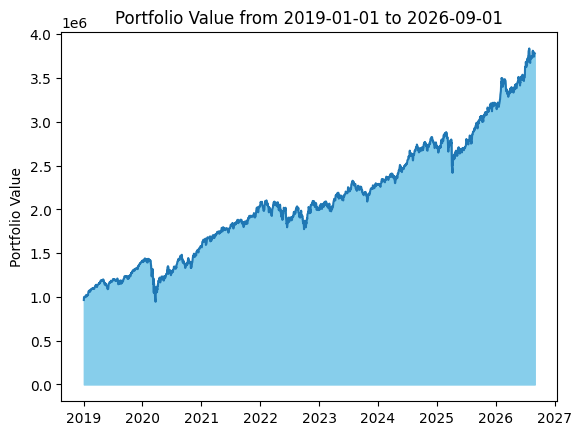

In [31]:
#Create a plot for the historical returns

#Align the data for plotting
plt.fill_between(df_pr.index, df_pr['Portfolio_Value'], color='skyblue')
plt.plot(df_pr['Portfolio_Value'])

#add plot labels
plt.title("Portfolio Value from " + startdt + " to " + enddt)
plt.ylabel("Portfolio Value")

#save it to the designated filepath for review
#plt.savefig('VAR_returns.png')

#show the plot
plt.show()

#close the plot
plt.close()


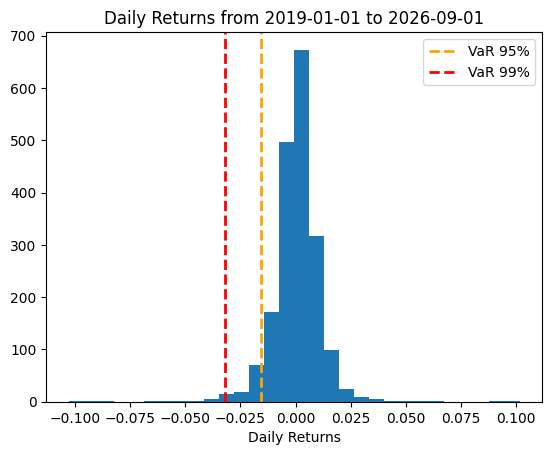

In [32]:
#Histogram of daily returns

#Align the data for plotting
plt.hist(df_pr['Total_Return'], bins=30)
plt.axvline(-var_hist_95, color='orange', linestyle='--', linewidth=2, label='VaR 95%')
plt.axvline(-var_hist_99, color='red', linestyle='--', linewidth=2, label='VaR 99%')

#add plot labels
plt.title("Daily Returns from " + startdt + " to " + enddt)
plt.xlabel("Daily Returns")

#show the legend
plt.legend()

#save it to the designated filepath for review
#plt.savefig('VAR_daily_hist.png')

#show the plot
plt.show()

#close the plot
plt.close()

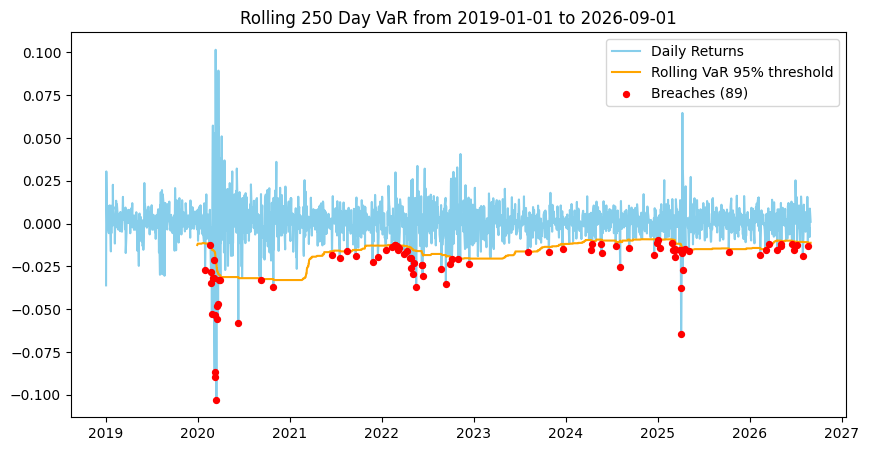

In [33]:
#Rolling VaR 

fig, ax = plt.subplots(figsize=(10, 5))

plt.plot(df_pr['Total_Return'], color='skyblue', label="Daily Returns")
plt.plot(-df_pr['rolling_VAR_95_prev'], color='orange', label="Rolling VaR 95% threshold")

#show only the breach days
breaches = df_pr[df_pr['rolling_VAR_95_breach']]
ax.scatter(breaches.index, breaches['Total_Return'],
           color='red', s=18, zorder=3, label=f'Breaches ({len(breaches)})')

#add plot labels
plt.title("Rolling 250 Day VaR from " + startdt + " to " + enddt)

#create a legend to show which series is which
plt.legend()

#save it to the designated filepath for review
#plt.savefig('VAR_daily_rolling.png')

plt.show()

#close the plot
plt.close()

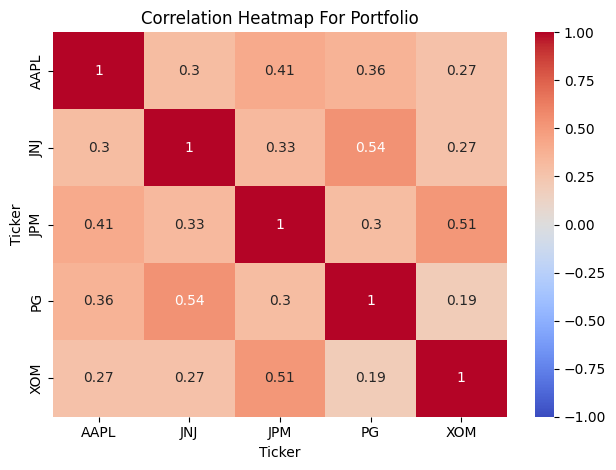

In [34]:
#Correlation heatmap

#Create a correlation matrix with seaborn
sns.heatmap(
    corr_matrix, 
    annot=True,        # Show the correlation values in the cells
    cmap='coolwarm',   # Color map (blue for negative, red for positive)
    vmin=-1, vmax=1,   # Fixed range for correlation coefficients
)

# 5. Display the plot
plt.title('Correlation Heatmap For Portfolio')
plt.tight_layout()

#save it to the designated filepath for review
#plt.savefig('VAR_corr_heatmap.png')

plt.show()

#close the plot
plt.close()